.config
t10k-images.idx3-ubyte.zip
sample_data


Unzipped successfully!


In [4]:
!ls /content/dataset

t10k-images.idx3-ubyte


In [5]:
!ls /content/dataset/DevanagariHandwrittenDigitDataset

ls: cannot access '/content/dataset/DevanagariHandwrittenDigitDataset': No such file or directory


In [ ]:
!ls /content/dataset/DevanagariHandwrittenDigitDataset/Train

digit_0  digit_2  digit_4  digit_6  digit_8
digit_1  digit_3  digit_5  digit_7  digit_9


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)
# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
import tensorflow as tf
from tensorflow import keras

num_classes = 10

model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(" Model compiled successfully")


 Model compiled successfully


Epoch 1/20
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4522 - loss: 1.6543
Epoch 1: val_loss improved from None to 0.39864, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6780 - loss: 1.0553 - val_accuracy: 0.8925 - val_loss: 0.3986
Epoch 2/20
369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8974 - loss: 0.3669
Epoch 2: val_loss improved from 0.39864 to 0.25325, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9076 - loss: 0.3290 - val_accuracy: 0.9276 - val_loss: 0.2532
Epoch 3/20
370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9299 - loss: 0.2440
Epoch 3: val_loss improved from 0.25325 to 0.19181, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9326 - loss: 0.2326 - val_accuracy: 0.9442 - 

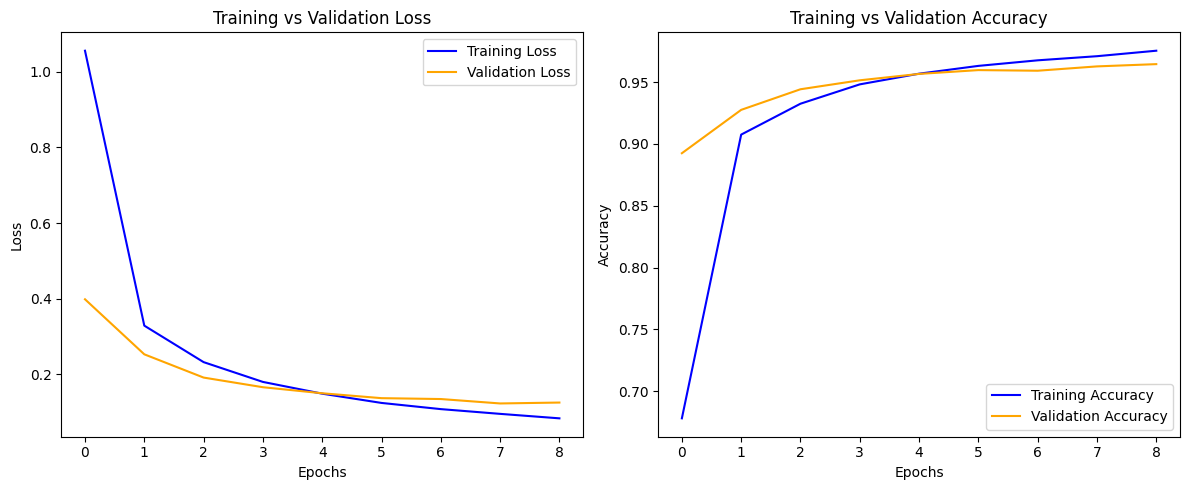

In [9]:
callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        verbose=1
    ),
]


history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(" Model trained successfully!")


import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss',   color='blue')
plt.plot(val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy',   color='blue')
plt.plot(val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

313/313 - 2s - 7ms/step - accuracy: 0.9647 - loss: 0.1159

Test Loss     : 0.1159
Test Accuracy : 0.9647 (96.47%)


In [11]:
model.save("devnagari_model.h5")
print("Model saved as devnagari_model.h5")

import tensorflow as tf
loaded_model = tf.keras.models.load_model("devnagari_model.h5")
print("Model loaded successfully!")


loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_acc:.4f} ({loaded_acc*100:.2f}%)")

Model saved as devnagari_model.h5
Model loaded successfully!
313/313 - 2s - 5ms/step - accuracy: 0.9647 - loss: 0.1159

Loaded Model Test Loss     : 0.1159
Loaded Model Test Accuracy : 0.9647 (96.47%)


In [12]:
import numpy as np

# Make predictions on all test images
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

# Count correct and incorrect
correct   = np.sum(predicted_labels == true_labels)
incorrect = np.sum(predicted_labels != true_labels)
total     = len(true_labels)

print(f"Total Images : {total}")
print(f"Correct   : {correct}")
print(f"Incorrect : {incorrect}")
print(f"Accuracy  : {correct/total*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Total Images : 10000
Correct   : 9647
Incorrect : 353
Accuracy  : 96.47%
